In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
sns.set_theme(palette="colorblind")

Dataset description: https://www.statsmodels.org/dev/datasets/generated/macrodata.html

In [2]:
from sktime.datasets.forecasting import Macroeconomic

df = Macroeconomic().load()[1]
df.index = df.index.astype('datetime64[ns]') 
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 203 entries, 1959-01-01 to 2009-07-01
Freq: QS-OCT
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   realgdp   203 non-null    float64
 1   realcons  203 non-null    float64
 2   realinv   203 non-null    float64
 3   realgovt  203 non-null    float64
 4   realdpi   203 non-null    float64
 5   cpi       203 non-null    float64
 6   m1        203 non-null    float64
 7   tbilrate  203 non-null    float64
 8   unemp     203 non-null    float64
 9   pop       203 non-null    float64
 10  infl      203 non-null    float64
 11  realint   203 non-null    float64
dtypes: float64(12)
memory usage: 20.6 KB


In [3]:
df.head()

,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
Period,,,,,,,,,,,,
1959-01-01,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1959-04-01,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
1959-07-01,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
1959-10-01,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
1960-01-01,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


# Train-test split

In [4]:
# 80% for training
train_size = int(df.shape[0]*0.8)

In [5]:
train_set = df.iloc[:train_size].copy()
test_set = df.iloc[train_size:].copy()

# EDA

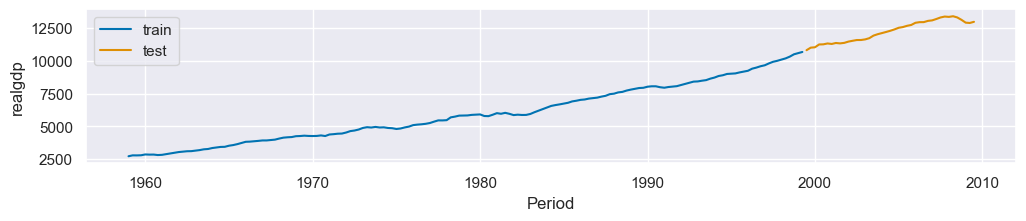

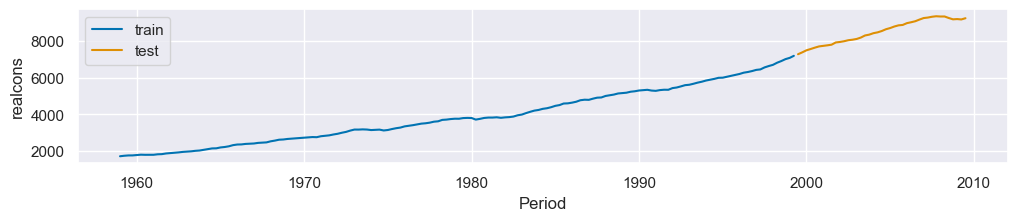

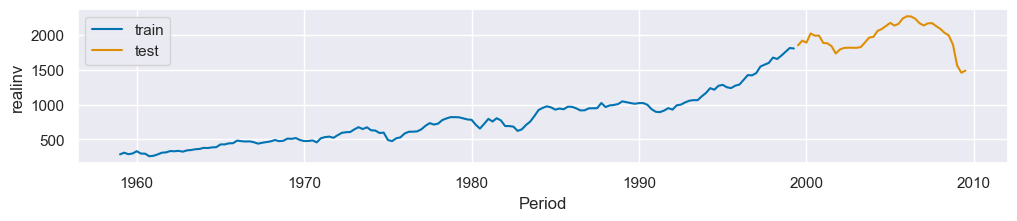

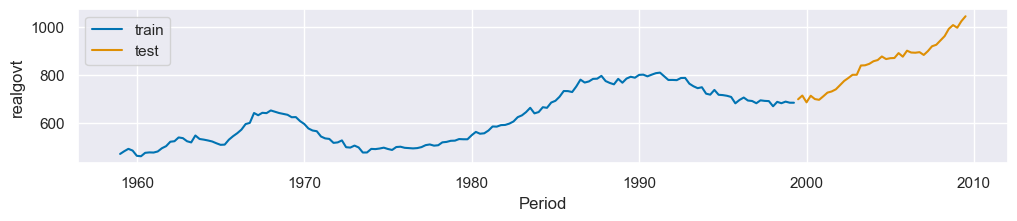

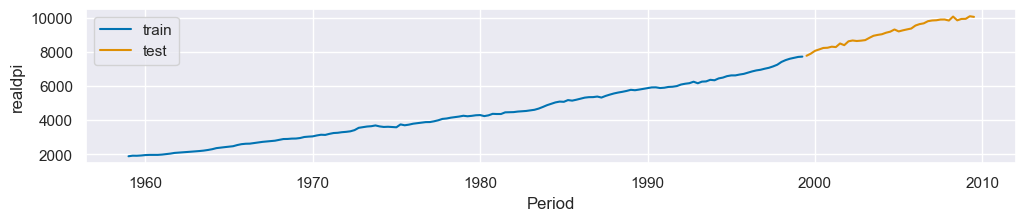

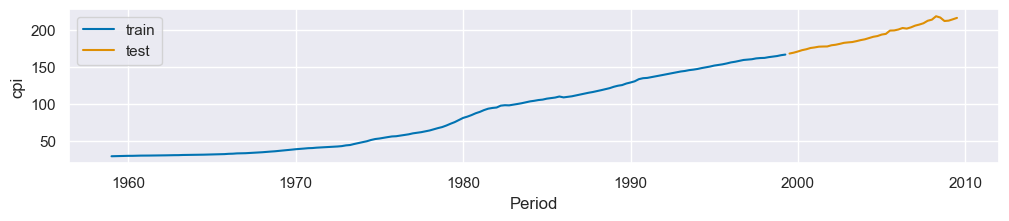

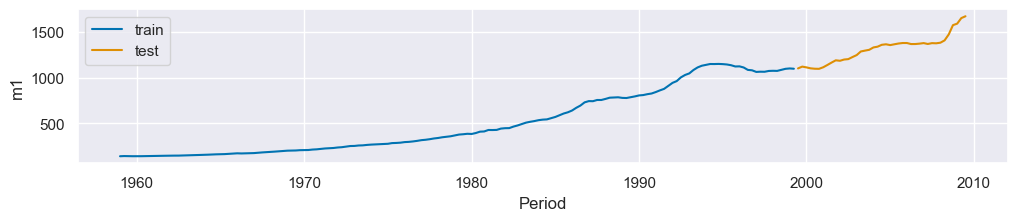

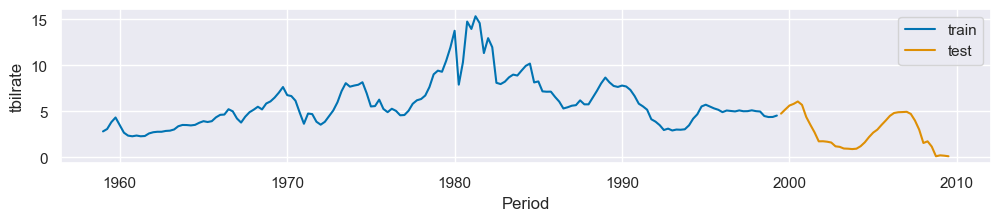

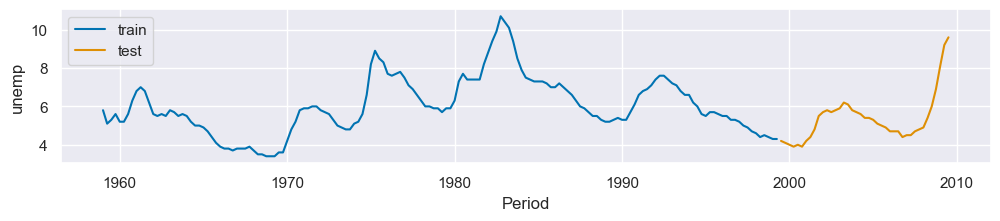

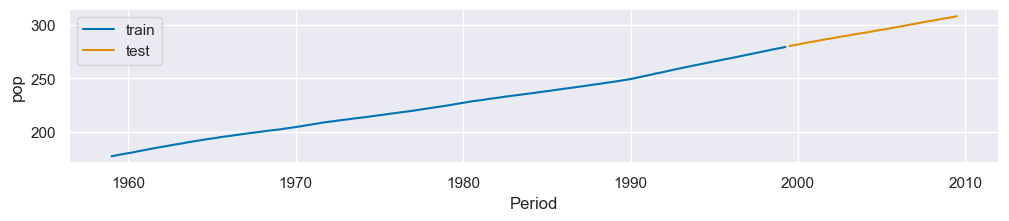

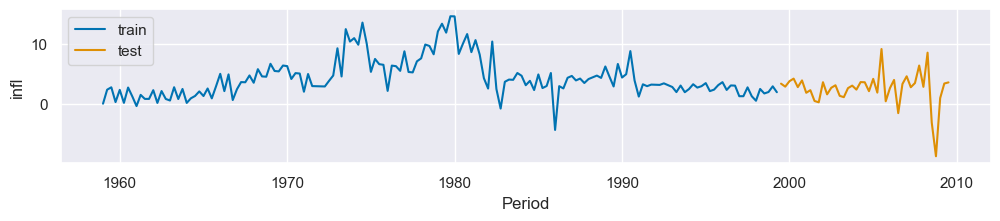

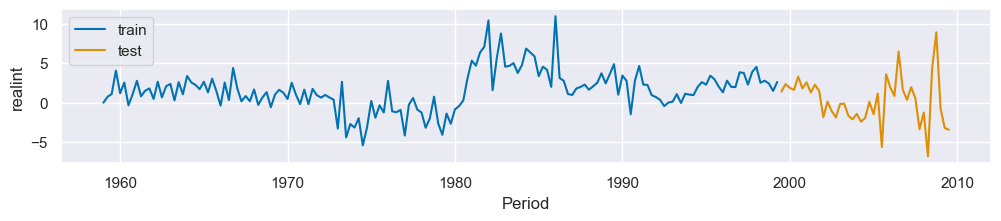

In [6]:
import matplotlib.pyplot as plt

for x in train_set.columns:
    fig, ax = plt.subplots()
    fig.set_size_inches(12, 2)
    sns.lineplot(data=train_set, x=train_set.index, y=x, label='train')
    sns.lineplot(data=test_set, x=test_set.index, y=x, label='test')

# Data preprocessing

In [7]:
# diff all variables

train_set = train_set.diff().bfill()
test_set = test_set.diff().bfill()
df = df.diff().bfill()

In [8]:
# create a seasonal dummy
df["quarter"] = df.index.quarter
train_set["quarter"] = train_set.index.quarter
test_set["quarter"] = test_set.index.quarter

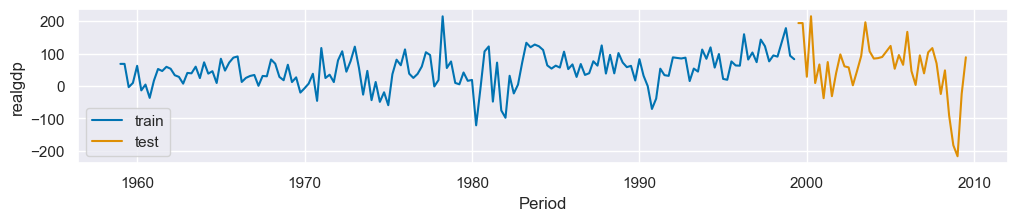

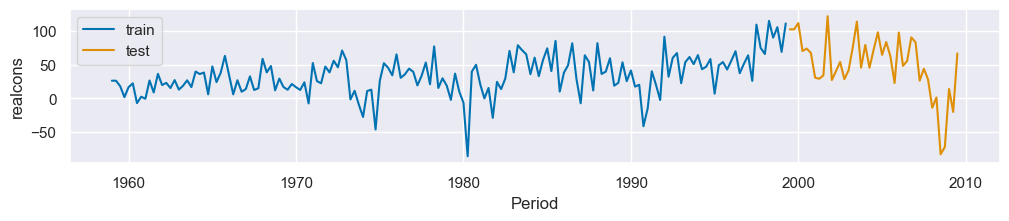

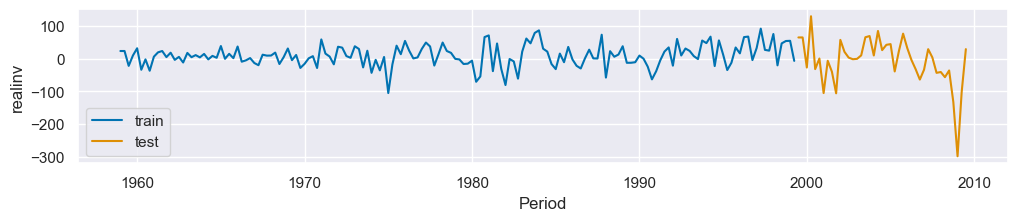

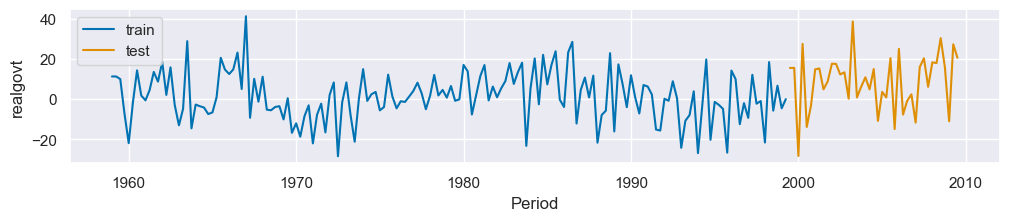

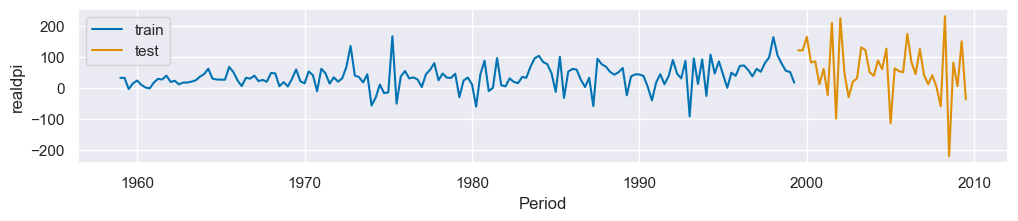

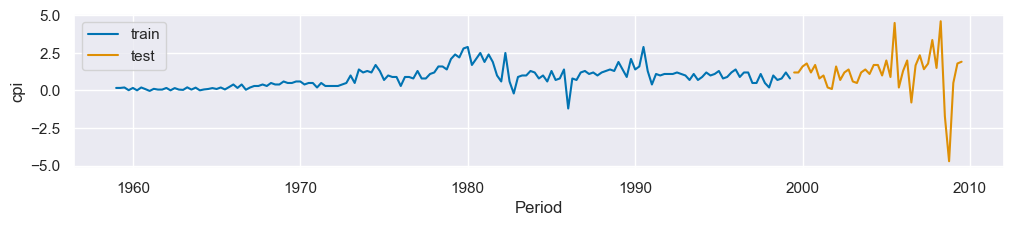

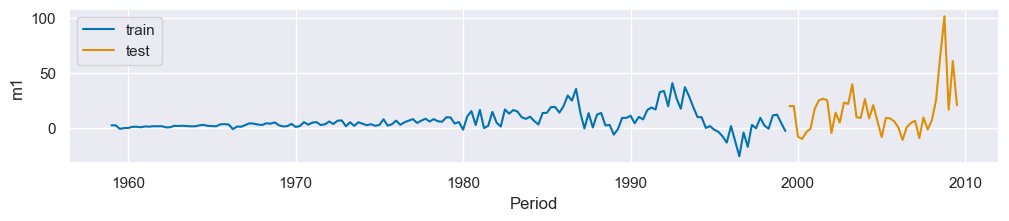

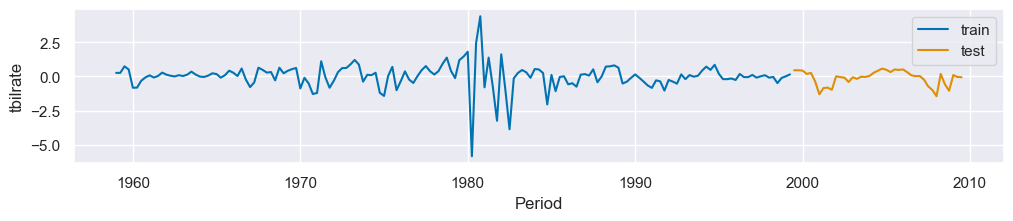

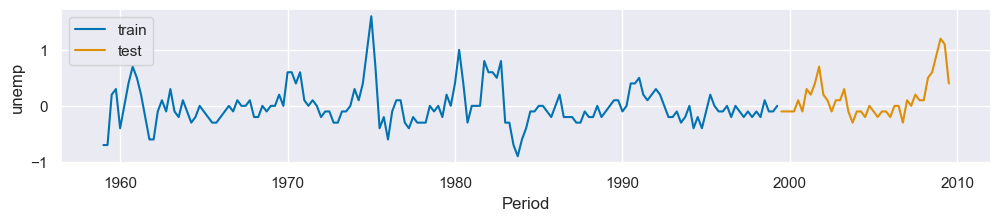

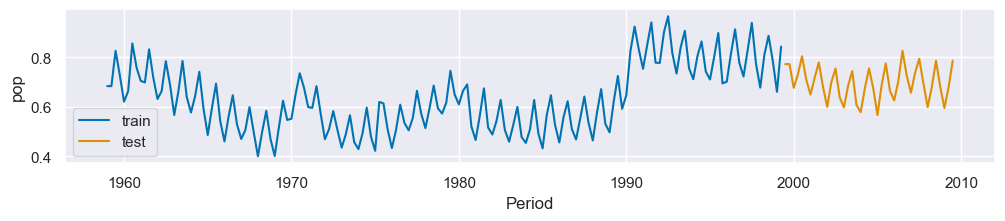

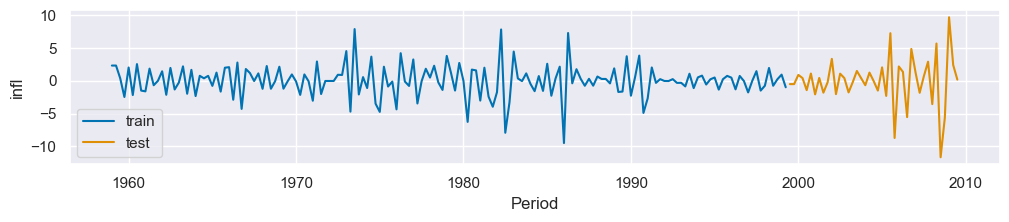

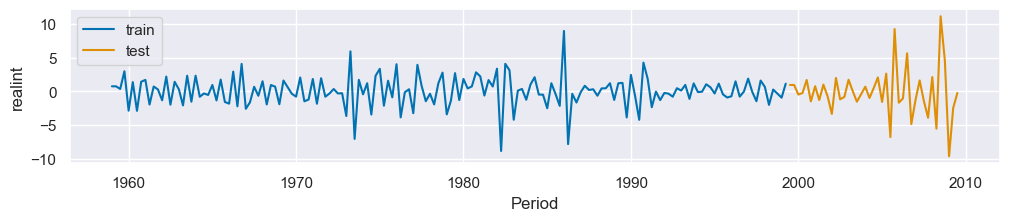

In [9]:
import matplotlib.pyplot as plt

for x in train_set.columns:
    if x == "quarter":
        continue
    fig, ax = plt.subplots()
    fig.set_size_inches(12, 2)
    sns.lineplot(data=train_set, x=train_set.index, y=x, label='train')
    sns.lineplot(data=test_set, x=test_set.index, y=x, label='test')

# Set up TimeSeriesFold

In [10]:
from skforecast.direct import ForecasterDirectMultiVariate
from skforecast.model_selection import TimeSeriesFold
from skforecast.model_selection import grid_search_forecaster_multiseries
from skforecast.model_selection import backtesting_forecaster_multiseries

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

In [11]:
cv = TimeSeriesFold(
         steps=1,
         initial_train_size=train_size,
         refit=False,
         allow_incomplete_fold=True
     )

# Baseline

In [12]:
from skforecast.recursive import ForecasterEquivalentDate
from skforecast.model_selection._validation import backtesting_forecaster


last_value_forecaster = ForecasterEquivalentDate(offset=1, n_offsets=1)

results_lv, predictions_backtest = backtesting_forecaster(
                                   forecaster=last_value_forecaster,
                                   y=df['realgdp'],
                                   cv=cv,
                                   metric=[root_mean_squared_error, 
                                           'mean_absolute_error'],
                                   n_jobs='auto',
                                   verbose=False,
                                   show_progress=True
                               )
results_lv.index = ["Last-Value"]
results_lv

  0%|          | 0/41 [00:00<?, ?it/s]

,root_mean_squared_error,mean_absolute_error
Last-Value,89.812104,74.017829


# Model development

## HP tuning

In [13]:
forecaster = ForecasterDirectMultiVariate(
                 estimator=RandomForestRegressor(random_state=7),
                 level='realgdp',
                 steps=1,
                 lags=4,
             )

In [14]:
X_train, y_train = forecaster.create_train_X_y(
                       series=train_set.drop(columns=["quarter"]),
                       exog=train_set['quarter']
                   )
X_train.head()

,realgdp_lag_1,realgdp_lag_2,realgdp_lag_3,realgdp_lag_4,realcons_lag_1,realcons_lag_2,realcons_lag_3,realcons_lag_4,realinv_lag_1,realinv_lag_2,...,pop_lag_4,infl_lag_1,infl_lag_2,infl_lag_3,infl_lag_4,realint_lag_1,realint_lag_2,realint_lag_3,realint_lag_4,quarter_step_1
Period,,,,,,,,,,,,,,,,,,,,,
1960-01-01,-0.782385,-1.037694,0.368572,0.368572,-1.090000,-0.541047,-0.263181,-0.263181,0.018737,-0.942279,...,0.367844,-1.031673,0.154445,0.956211,0.956211,1.319644,0.147327,0.321832,0.321832,1
1960-04-01,0.251842,-0.782385,-1.037694,0.368572,-0.585098,-1.090000,-0.541047,-0.263181,0.691505,0.018737,...,0.367844,0.832227,-1.031673,0.154445,0.956211,-1.293460,1.319644,0.147327,0.321832,2
1960-07-01,-1.233570,0.251842,-0.782385,-1.037694,-0.395337,-0.585098,-1.090000,-0.541047,-1.303442,0.691505,...,1.436366,-0.907689,0.832227,-1.031673,0.154445,0.599251,-1.293460,1.319644,0.147327,3
1960-10-01,-0.882009,-1.233570,0.251842,-0.782385,-1.394974,-0.395337,-0.585098,-1.090000,-0.341519,-1.303442,...,0.704092,1.047133,-0.907689,0.832227,-1.031673,-1.302409,0.599251,-1.293460,1.319644,4
1961-01-01,-1.686166,-0.882009,-1.233570,0.251842,-1.073057,-1.394974,-0.395337,-0.585098,-1.395450,-0.341519,...,-0.102904,-0.626657,1.047133,-0.907689,0.832227,0.626098,-1.302409,0.599251,-1.293460,1


In [15]:
y_train

{np.int64(1): Period
 1960-01-01    0.251842
 1960-04-01   -1.233570
 1960-07-01   -0.882009
 1960-10-01   -1.686166
 1961-01-01   -0.646550
                 ...   
 1998-04-01    0.807510
 1998-07-01    1.663008
 1998-10-01    2.530654
 1999-01-01    0.861437
 1999-04-01    0.651099
 Freq: QS-OCT, Name: realgdp_step_1, Length: 158, dtype: float64}

In [16]:
lags_grid = {
    '2 lags': 2,
    '4 lags': 4
}

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 7, 10]
}

cv_hp_search = TimeSeriesFold(
         steps=1,
         initial_train_size=int(train_size*0.8),
         fold_stride=None,
         refit=False
     )

results_search = grid_search_forecaster_multiseries(
    forecaster=forecaster,
    series=train_set.drop(columns=['quarter']),
    exog=train_set['quarter'],
    lags_grid=lags_grid,
    param_grid=param_grid,
    cv=cv_hp_search,
    levels=None,
    metric=[root_mean_squared_error, 'mean_absolute_error'],
    aggregate_metric='weighted_average',
    suppress_warnings=True,
    return_best=True
)

results_search.head(3)

lags grid:   0%|          | 0/2 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

,levels,lags,lags_label,params,root_mean_squared_error,mean_absolute_error,max_depth,n_estimators
0,[realgdp],"[1, 2]",2 lags,"{'max_depth': 7, 'n_estimators': 200}",47.822538,38.229168,7,200
1,[realgdp],"[1, 2]",2 lags,"{'max_depth': 3, 'n_estimators': 200}",47.825462,38.526447,3,200
2,[realgdp],"[1, 2]",2 lags,"{'max_depth': 10, 'n_estimators': 200}",47.889389,38.316584,10,200


In [17]:
best_params = results_search['params'].iat[0]
best_params

{'max_depth': 7, 'n_estimators': 200}

In [18]:
best_lags = results_search['lags'].iat[0]
best_lags

array([1, 2])

## Evaluation on test data

In [19]:
results, predictions = backtesting_forecaster_multiseries(
                                     forecaster=forecaster,
                                     series=df.drop("quarter", axis=1),
                                     exog=df["quarter"],
                                     cv=cv,
                                     metric=[root_mean_squared_error, 'mean_absolute_error']
                                 )
results.index = ["Random Forest"]
results

  0%|          | 0/41 [00:00<?, ?it/s]

,levels,root_mean_squared_error,mean_absolute_error
Random Forest,realgdp,74.979117,54.635542


In [20]:
predictions.head(4)

,level,fold,pred
1999-07-01,realgdp,0,89.348536
1999-10-01,realgdp,1,97.925582
2000-01-01,realgdp,2,96.779110
2000-04-01,realgdp,3,100.582625


In [21]:
predictions['level'].unique()

array(['realgdp'], dtype=object)

## Plot predictions

<Axes: >

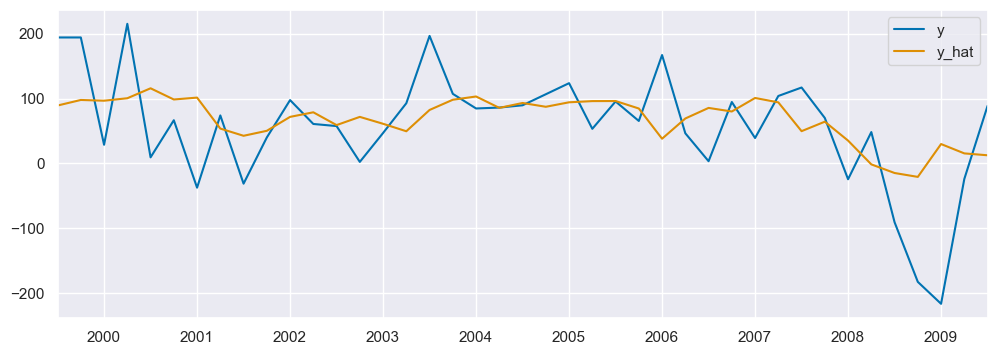

In [22]:
y_hat = predictions['pred']
tdf = pd.DataFrame({"y": test_set['realgdp'], "y_hat": y_hat})
tdf.plot(figsize=(12,4))

# Summary table

In [23]:
tdf = pd.concat([results_lv, results], axis=0)
tdf

,root_mean_squared_error,mean_absolute_error,levels
Last-Value,89.812104,74.017829,NaN
Random Forest,74.979117,54.635542,realgdp


# Citing this notebook

If you use this notebook in your work, please cite it as follows:
    
Pekar, V. (2026). Business Forecasting. Lecture examples and exercises. (Version 1.0.0). URL: https://github.com/vpekar/bf